# Importing the dependencies

In [90]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

# Loading the dataset

In [91]:
df=pd.read_csv('urban_pluvial_flood_risk_dataset.csv')

# Understanding the data

In [92]:
df.shape

(2963, 17)

In [93]:
df.head()

,segment_id,city_name,admin_ward,latitude,longitude,catchment_id,elevation_m,dem_source,land_use,soil_group,drainage_density_km_per_km2,storm_drain_proximity_m,storm_drain_type,rainfall_source,historical_rainfall_intensity_mm_hr,return_period_years,risk_labels
0,SEG-00001,"Colombo, Sri Lanka",Borough East,6.920633,79.912600,CAT-136,NaN,Copernicus_EEA-10_v5,Institutional,NaN,4.27,160.5,CurbInlet,ERA5,39.4,50,monitor
1,SEG-00002,"Chennai, India",Ward D,13.076487,80.281774,CAT-049,-2.19,Copernicus_EEA-10_v5,Residential,D,7.54,NaN,OpenChannel,ERA5,56.8,25,ponding_hotspot|low_lying|event_2025-05-02
2,SEG-00003,"Ahmedabad, India",Sector 12,23.019473,72.638578,CAT-023,30.88,SRTM_3arc,Industrial,B,11.00,152.5,OpenChannel,IMD,16.3,5,monitor
3,SEG-00004,"Hong Kong, China",Sector 14,22.302602,114.078673,CAT-168,24.28,SRTM_3arc,Residential,B,7.32,37.0,Manhole,ERA5,77.0,10,monitor
4,SEG-00005,"Durban, South Africa",Sector 5,-29.887602,30.911008,CAT-171,35.70,SRTM_3arc,Industrial,C,4.50,292.4,OpenChannel,ERA5,20.8,5,monitor


In [94]:
df.tail()

,segment_id,city_name,admin_ward,latitude,longitude,catchment_id,elevation_m,dem_source,land_use,soil_group,drainage_density_km_per_km2,storm_drain_proximity_m,storm_drain_type,rainfall_source,historical_rainfall_intensity_mm_hr,return_period_years,risk_labels
2958,SEG-02959,"Paris, France",Ward B,48.872870,2.246250,CAT-036,30.46,Copernicus_GLO-30_v2023,Residential,C,NaN,78.8,GratedInlet,NaN,46.5,10,monitor
2959,SEG-02960,"Shanghai, China",Sector 17,31.195529,121.435540,CAT-050,-3.00,SRTM_3arc,Industrial,C,5.54,4.9,OpenChannel,LocalGauge,70.6,5,ponding_hotspot|low_lying|event_2024-07-26
2960,SEG-02961,"Vancouver, Canada",Sector 12,49.162783,-123.037084,CAT-052,14.16,Copernicus_GLO-90_v2022,Green,B,NaN,236.1,GratedInlet,NaN,27.7,2,monitor
2961,SEG-02962,"Lagos, Nigeria",Zone V,6.504570,3.388571,CAT-092,7.00,Copernicus_GLO-30_v2023,Industrial,B,8.74,294.8,OpenChannel,ERA5,131.6,100,extreme_rain_history|low_lying
2962,SEG-02963,"Osaka, Japan",Zone IV,34.740562,135.469263,CAT-169,56.00,SRTM_3arc,Commercial,C,4.44,80.8,OpenChannel,ERA5,43.1,2,monitor


In [95]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2963 entries, 0 to 2962
Data columns (total 17 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   segment_id                           2963 non-null   object 
 1   city_name                            2963 non-null   object 
 2   admin_ward                           2963 non-null   object 
 3   latitude                             2963 non-null   float64
 4   longitude                            2963 non-null   float64
 5   catchment_id                         2963 non-null   object 
 6   elevation_m                          2802 non-null   float64
 7   dem_source                           2963 non-null   object 
 8   land_use                             2963 non-null   object 
 9   soil_group                           2601 non-null   object 
 10  drainage_density_km_per_km2          2679 non-null   float64
 11  storm_drain_proximity_m       

# column description

segment_id → Unique ID for each road/catchment segment.

city_name → City where the segment is located.

admin_ward → Administrative ward/sector of the city.

latitude, longitude → Geographic coordinates of the segment.

catchment_id → ID for the catchment area (drainage basin).

elevation_m → Elevation above sea level (in meters).

dem_source → Source of elevation data (e.g., Copernicus, SRTM).

land_use → Type of land use (Residential, Industrial, Institutional, etc.).

soil_group → Soil classification (A, B, C, D) affecting infiltration.

drainage_density_km_per_km2 → Drainage network density in the area.

storm_drain_proximity_m → Distance to the nearest storm drain (meters).

storm_drain_type → Type of drainage (Open Channel, Curb Inlet, Manhole, etc.).

rainfall_source → Source of rainfall data (ERA5, IMD, etc.).

historical_rainfall_intensity_mm_hr → Past rainfall intensity (mm/hr).

return_period_years → Flood return period (5, 10, 25, 50 years).

risk_labels → Flood risk status (e.g., monitor, ponding_hotspot, low_lying, with event date).

# Data cleaning

In [96]:
df.duplicated().any()

np.False_

In [97]:
df['soil_group']=df['soil_group'].fillna('Unknown')
df['elevation_m']=df['elevation_m'].fillna(df['elevation_m'].mean())
df['drainage_density_km_per_km2']=df['drainage_density_km_per_km2'].fillna(df['drainage_density_km_per_km2'].mean())
df['storm_drain_proximity_m']=df['storm_drain_proximity_m'].fillna(df['storm_drain_proximity_m'].mean())
df['storm_drain_type']=df['storm_drain_type'].fillna('Unknown')
df['rainfall_source']=df['rainfall_source'].fillna(df['rainfall_source'].mode()[0])

# Data Transformation

In [98]:
df['city']=df['city_name'].str.split(',',n=1,expand=True)[0]
df['country']=df['city_name'].str.split(',',n=1,expand=True)[1]
df=df.drop(columns=['city_name'])

In [99]:
df.columns

Index(['segment_id', 'admin_ward', 'latitude', 'longitude', 'catchment_id',
       'elevation_m', 'dem_source', 'land_use', 'soil_group',
       'drainage_density_km_per_km2', 'storm_drain_proximity_m',
       'storm_drain_type', 'rainfall_source',
       'historical_rainfall_intensity_mm_hr', 'return_period_years',
       'risk_labels', 'city', 'country'],
      dtype='object')

In [100]:
lst=['segment_id','city','country','admin_ward','latitude','longitude','catchment_id','elevation_m','dem_source','land_use','soil_group','drainage_density_km_per_km2','storm_drain_proximity_m','storm_drain_type','rainfall_source','historical_rainfall_intensity_mm_hr','return_period_years','risk_labels']
df=df[lst]

# Analysis

1. ----------------------------------------------------Dataset Basics-------------------------------------------------

How many total records are there in the dataset?

What are the different risk_labels?

How many segments fall under each risk label?

2. -------------------------------------------------Geography & Environment----------------------------------------------

Do low elevation areas have more flood risk than high elevation areas?

Which soil type (A–D) is most common in risky areas?

Which land use type (Residential, Industrial, Institutional) shows the highest flood risk?

3. ------------------------------------------------Infrastructure------------------------------------------------

Are places closer to drains safer compared to those far away?

Which drain type (Open Channel, Manhole, Curb Inlet) is seen more in risky areas?

4. ------------------------------------------------Rainfall------------------------------------------------

Do areas with higher rainfall intensity face more flooding?

Does flood risk increase with longer return periods (5 vs 25 vs 50 years)?

5. ------------------------------------------------Location Insights------------------------------------------------

Which city has the highest number of flood hotspots?

Within a city, which wards are most affected?

6.------------------------------------------------Combined Factors & Trends------------------------------------------------

Which 2–3 factors combined (e.g., low elevation + residential + high rainfall) appear most often in risky areas?

What patterns or trends can be seen in the dataset overall?

7.------------------------------------------------Decision & Action------------------------------------------------

Which areas (or regions) are at highest risk of flooding?

Which locations must be prioritized for flood prevention measures?

Which areas are safest for new houses or infrastructure?

Which villages/towns need early flood warning systems immediately?

Should resources (funds, manpower) be focused on high rainfall zones, clay soil regions, or urbanized areas?

What is the top recommendation for reducing flood risk in this region?

1. ----------------------------------------------------Dataset Basics-------------------------------------------------



How many total records are there in the dataset?

In [101]:
df.shape[0]

2963

What are the different risk_labels?

In [102]:
df['risk_labels'].unique()

array(['monitor', 'ponding_hotspot|low_lying|event_2025-05-02',
       'extreme_rain_history', 'low_lying|event_2024-02-14', 'low_lying',
       'ponding_hotspot|extreme_rain_history|low_lying|event_2024-09-25',
       'monitor|event_2022-09-04',
       'ponding_hotspot|low_lying|event_2024-07-31',
       'ponding_hotspot|extreme_rain_history|event_2022-10-11',
       'low_lying|sparse_drainage',
       'ponding_hotspot|low_lying|event_2024-07-21',
       'ponding_hotspot|extreme_rain_history|low_lying|event_2023-05-16',
       'sparse_drainage', 'sparse_drainage|event_2024-05-19',
       'ponding_hotspot|extreme_rain_history|low_lying|event_2023-09-13',
       'low_lying|sparse_drainage|event_2023-07-20',
       'extreme_rain_history|low_lying', 'ponding_hotspot|low_lying',
       'ponding_hotspot|low_lying|event_2024-08-16',
       'ponding_hotspot|low_lying|event_2024-03-31',
       'low_lying|event_2024-03-24',
       'ponding_hotspot|low_lying|event_2022-12-18',
       'low_lying|

How many segments fall under each risk label?

In [103]:
df.groupby('risk_labels')['segment_id'].value_counts()

risk_labels                       segment_id
extreme_rain_history              SEG-00006     1
                                  SEG-00019     1
                                  SEG-00061     1
                                  SEG-00074     1
                                  SEG-00080     1
                                               ..
sparse_drainage|event_2024-09-03  SEG-00764     1
sparse_drainage|event_2024-11-13  SEG-00895     1
sparse_drainage|event_2025-02-13  SEG-01084     1
sparse_drainage|event_2025-05-16  SEG-00338     1
sparse_drainage|event_2025-06-17  SEG-00531     1
Name: count, Length: 2963, dtype: int64

2. -------------------------------------------------Geography & Environment----------------------------------------------



Do low elevation areas have more flood risk than high elevation areas?

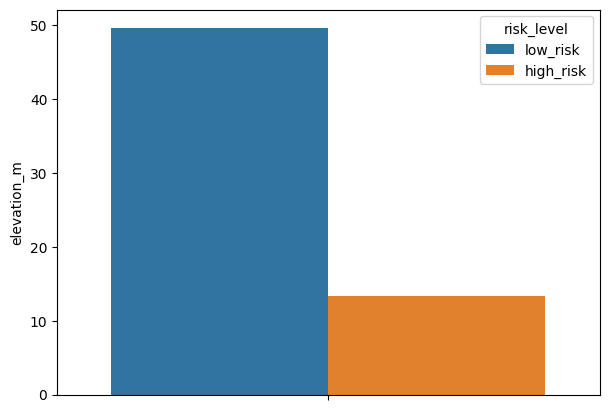

In [113]:
df['risk_level']=df['risk_labels'].str.contains('ponding_hotspot|extreme_rain_history|low_lying|sparse_drainage')
plt.figure(figsize=(7,5))
sns.barplot(df,y='elevation_m',hue='risk_level',errorbar=None)
plt.legend(title='risk_level',labels=['low_risk','high_risk'])
plt.show()

OBSERVATION:

Yes low elevation leads to high risk of flood

Which soil type (A–D) is most common in risky areas?

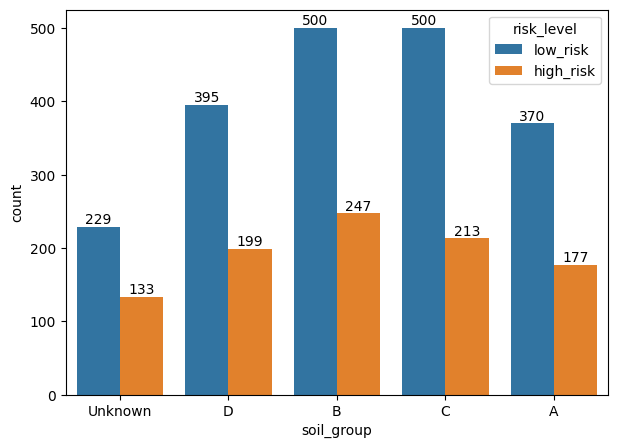

In [117]:
plt.figure(figsize=(7,5))
a=sns.countplot(df,x='soil_group',hue='risk_level')
for i in a.containers:
    a.bar_label(i)
plt.legend(title='risk_level',labels=['low_risk','high_risk'])
plt.show()

OBSERVATION:
Soil group B is more in risky areas

Which land use type (Residential, Industrial, Institutional) shows the highest flood risk?

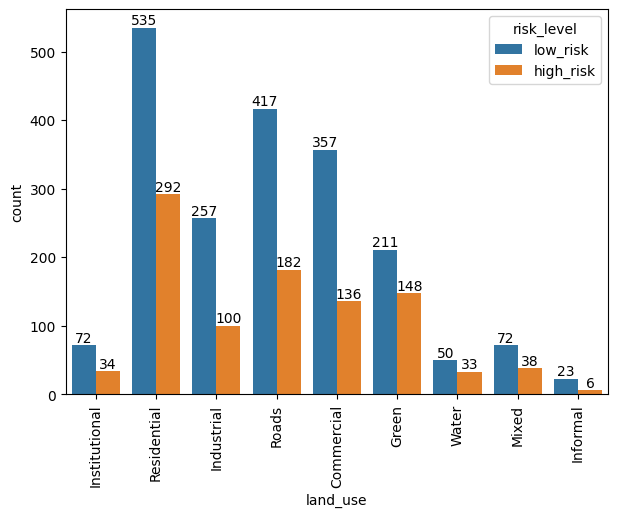

In [119]:
plt.figure(figsize=(7,5))
a=sns.countplot(df,x='land_use',hue='risk_level')
for i in a.containers:
    a.bar_label(i)
plt.legend(title='risk_level',labels=['low_risk','high_risk'])
plt.xticks(rotation=90)
plt.show()

OBSERVATION:

Residential areas shows the highest flood risk

3. ------------------------------------------------Infrastructure------------------------------------------------




Are places closer to drains safer compared to those far away?

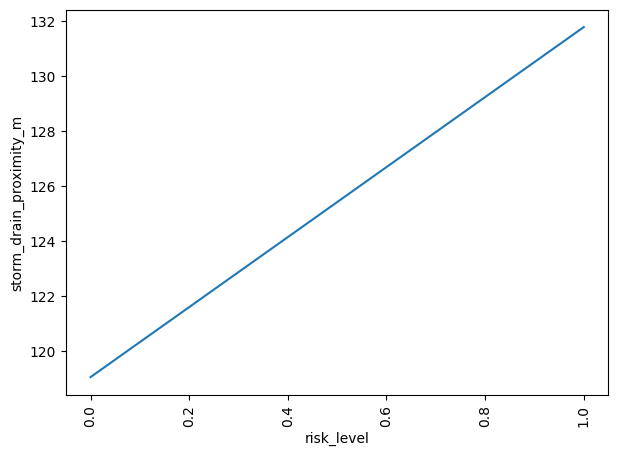

In [126]:
plt.figure(figsize=(7,5))
a=sns.lineplot(df,y='storm_drain_proximity_m',x='risk_level',errorbar=None)
for i in a.containers:
    a.bar_label(i)

plt.xticks(rotation=90)
plt.show()

OBSERVATION:

We can clearly observe that farther the drains more the risk and vice versa

Which drain type (Open Channel, Manhole, Curb Inlet) is seen more in risky areas?

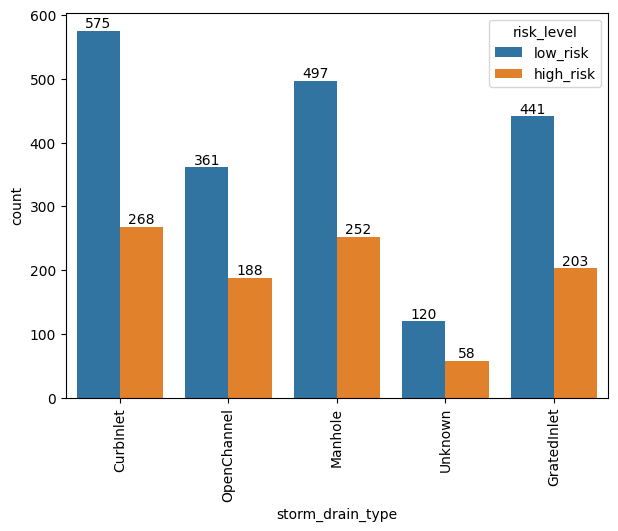

In [127]:
plt.figure(figsize=(7,5))
a=sns.countplot(df,x='storm_drain_type',hue='risk_level')
for i in a.containers:
    a.bar_label(i)
plt.legend(title='risk_level',labels=['low_risk','high_risk'])
plt.xticks(rotation=90)
plt.show()

OBSERVATION:

Curblnet and Manhole are found more risky

4. ------------------------------------------------Rainfall------------------------------------------------



Do areas with higher rainfall intensity face more flooding?

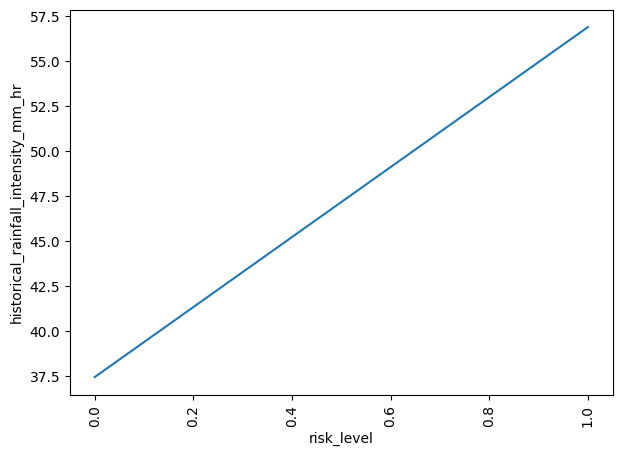

In [128]:
plt.figure(figsize=(7,5))
a=sns.lineplot(df,y='historical_rainfall_intensity_mm_hr',x='risk_level',errorbar=None)
for i in a.containers:
    a.bar_label(i)

plt.xticks(rotation=90)
plt.show()

OBSERVATION:

Yes areas with higher rainfall intensity face more flooding

Does flood risk increase with longer return periods (5 vs 25 vs 50 years)?

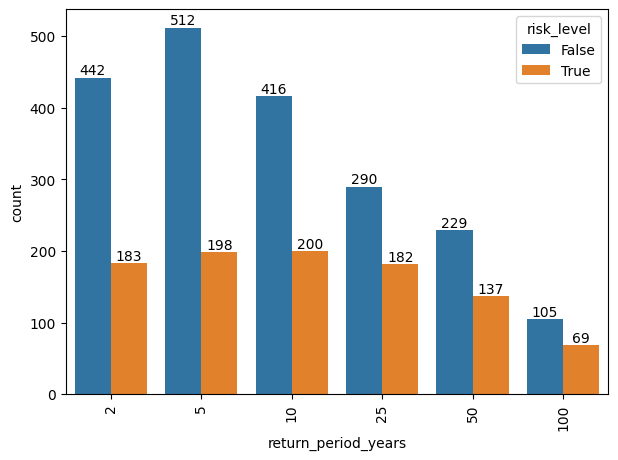

In [134]:
plt.figure(figsize=(7,5))
a=sns.countplot(df,x='return_period_years',hue='risk_level')
for i in a.containers:
    a.bar_label(i)

plt.xticks(rotation=90)
plt.show()

OBSERVATION:

No 

5. ------------------------------------------------Location Insights------------------------------------------------



Which city has the highest number of flood hotspots?

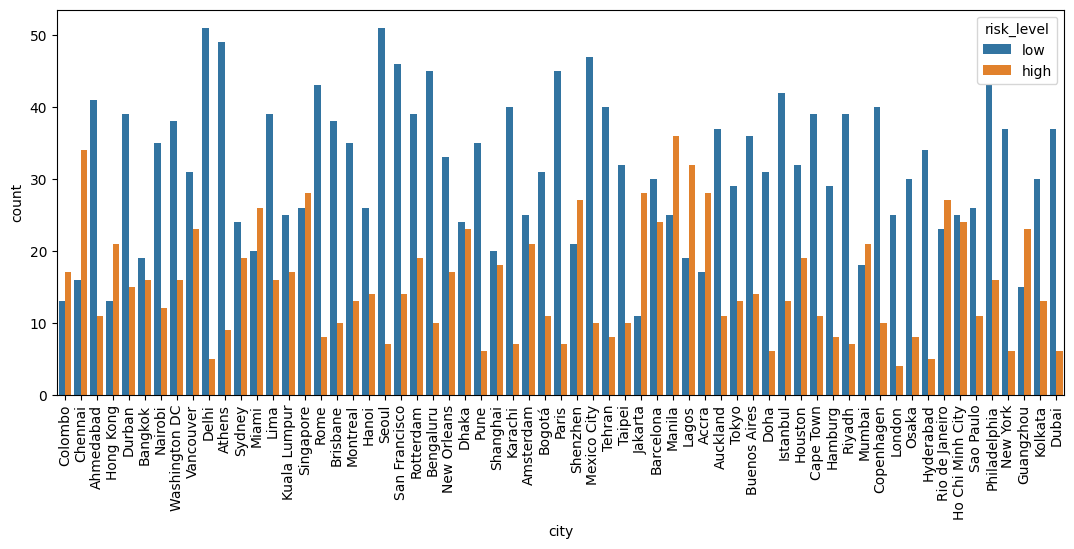

In [137]:
plt.figure(figsize=(13,5))
a=sns.countplot(df,x='city',hue='risk_level')

plt.legend(title='risk_level',labels=['low','high'])
plt.xticks(rotation=90)
plt.show()

Manila

Within a city, which wards are most affected?

6.------------------------------------------------Combined Factors & Trends------------------------------------------------


Which 2–3 factors combined (e.g., low elevation + residential + high rainfall) appear most often in risky areas?

<Axes: >

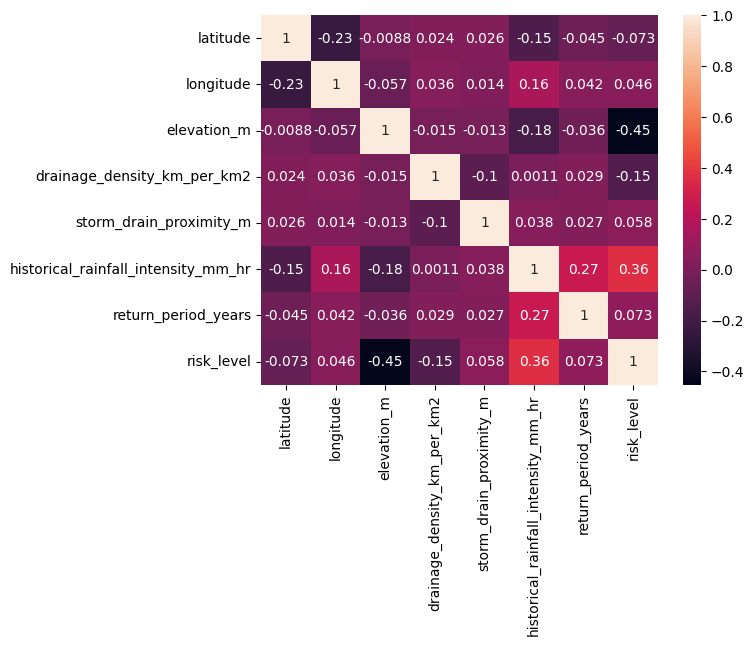

In [141]:
plt.Figure(figsize=(13,8))
sns.heatmap(df.corr(numeric_only=True),annot=True)

In [142]:
df.columns

Index(['segment_id', 'city', 'country', 'admin_ward', 'latitude', 'longitude',
       'catchment_id', 'elevation_m', 'dem_source', 'land_use', 'soil_group',
       'drainage_density_km_per_km2', 'storm_drain_proximity_m',
       'storm_drain_type', 'rainfall_source',
       'historical_rainfall_intensity_mm_hr', 'return_period_years',
       'risk_labels', 'risk_level'],
      dtype='object')

What patterns or trends can be seen in the dataset overall?

In the overall dataset the risk level or flood level increases based on Soil group,landuse,drains distance,drain type , drain promximity and historical rainfall intensity matters and are contributing factors

as the drain proximity increases risk also increases same with rainfall intensity

7.------------------------------------------------Decision & Action------------------------------------------------




Which areas (or regions) are at highest risk of flooding?

 Ans..Areas with soil type B , that are far from drains and has high historical rainfall intensity has the highest risk of flooding

Which locations must be prioritized for flood prevention measures?

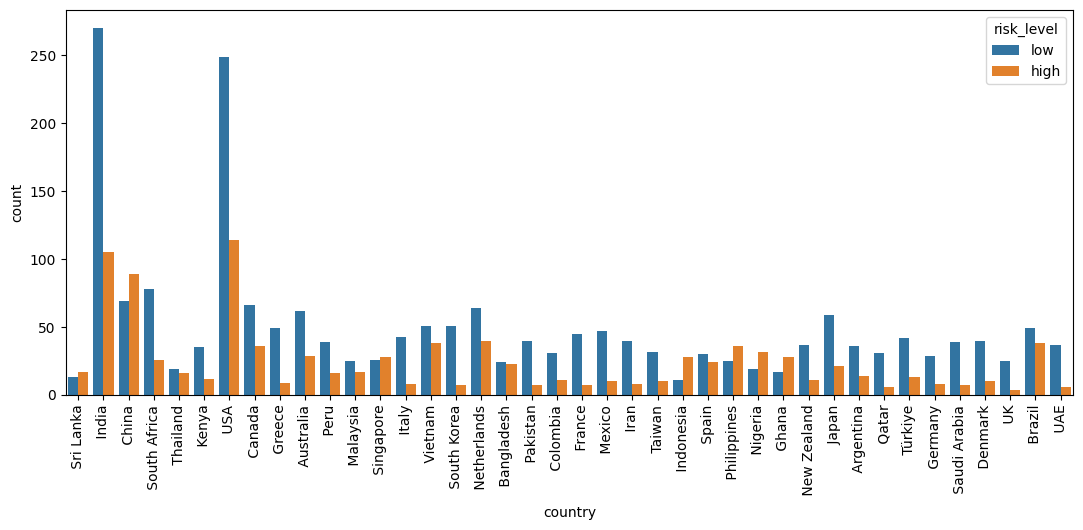

In [143]:
plt.figure(figsize=(13,5))
a=sns.countplot(df,x='country',hue='risk_level')

plt.legend(title='risk_level',labels=['low','high'])
plt.xticks(rotation=90)
plt.show()

USA India and China needs more prevention and Cities like Manlia , chennai, Ro en etc must be prioritized

Which areas are safest for new houses or infrastructure?

Areas with close drains or nearby drains , with low rainfall intensity 

Which villages/towns need early flood warning systems immediately?

#repeated

Should resources (funds, manpower) be focused on high rainfall zones, clay soil regions, or urbanized areas?

High rainfall zones

What is the top recommendation for reducing flood risk in this region?


Build and maintain the drains properly so that the rain water flows flawlessly